
🧪 PROTEIN STRUCTURE ANALYSIS RESULTS
UniProt ID: P06493



🔬 3D Protein Structure:


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


📊 Amino Acid Composition:


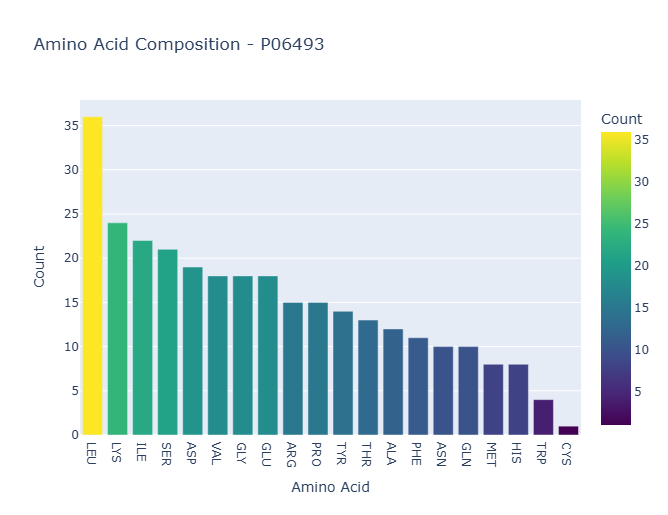


📊 Residue Type Distribution:


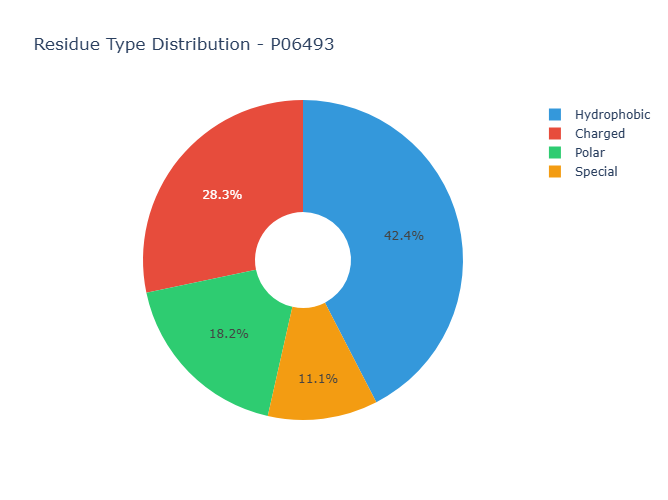


💾 FILES GENERATED:
   📁 PDB File: P06493.pdb
   📄 Summary File: P06493_summary.txt

✅ STEP 1 COMPLETED SUCCESSFULLY!


📌 For Step 2, use:
   pdb_file = 'P06493.pdb'
   quality_score = 0.85


In [5]:
# ===== STEP 1: PROTEIN STRUCTURE ANALYSIS =====
# Run this entire cell in Jupyter Lab

import requests
import py3Dmol
import plotly.express as px
import plotly.graph_objects as go
from Bio.PDB import PDBParser
import numpy as np
import pandas as pd
import os
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

def get_alphafold_structure(uniprot_id):
    """Fetch AlphaFold structure from API"""
    url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            data = response.json()
            if data and len(data) > 0:
                pdb_url = data[0]['pdbUrl']
                pdb_content = requests.get(pdb_url, timeout=30).text
                return pdb_content
        print(f"❌ No structure found for {uniprot_id}")
        return None
    except Exception as e:
        print(f"❌ Error fetching structure: {e}")
        return None

def calculate_protein_quality(pdb_file):
    """Calculate protein quality metrics from B-factors (pLDDT)"""
    try:
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure('protein', pdb_file)
        
        b_factors = []
        for model in structure:
            for chain in model:
                for residue in chain:
                    for atom in residue:
                        if atom.get_name() == 'CA':
                            b_factors.append(atom.get_bfactor())
        
        if b_factors:
            avg_plddt = np.mean(b_factors)
            min_plddt = np.min(b_factors)
            max_plddt = np.max(b_factors)
            low_conf_ratio = sum(1 for b in b_factors if b < 70) / len(b_factors)
            
            if avg_plddt >= 90:
                quality = "VERY HIGH (Excellent)"
                quality_score = 1.0
            elif avg_plddt >= 70:
                quality = "HIGH (Good)"
                quality_score = 0.85
            elif avg_plddt >= 50:
                quality = "MODERATE (Acceptable)"
                quality_score = 0.60
            else:
                quality = "LOW (Poor - use with caution)"
                quality_score = 0.30
            
            return {
                'avg_plddt': avg_plddt,
                'min_plddt': min_plddt,
                'max_plddt': max_plddt,
                'low_confidence_ratio': low_conf_ratio,
                'quality': quality,
                'quality_score': quality_score
            }
    except:
        pass
    return None

def create_aa_chart(aa_counts, uniprot_id):
    """Create amino acid composition bar chart"""
    if not aa_counts:
        return None
    aa_df = pd.DataFrame(list(aa_counts.items()), columns=['Amino Acid', 'Count'])
    aa_df = aa_df.sort_values('Count', ascending=False)
    fig = px.bar(aa_df, x='Amino Acid', y='Count', 
                 title=f'Amino Acid Composition - {uniprot_id}',
                 color='Count', color_continuous_scale='viridis')
    fig.update_layout(height=500, width=900, showlegend=False)
    return fig

def create_residue_chart(aa_counts, uniprot_id):
    """Create residue type distribution pie chart"""
    hydrophobic = ['ALA', 'VAL', 'LEU', 'ILE', 'MET', 'PHE', 'TRP', 'PRO']
    polar = ['SER', 'THR', 'ASN', 'GLN']
    charged = ['ASP', 'GLU', 'ARG', 'LYS', 'HIS']
    special = ['CYS', 'GLY', 'TYR']
    
    counts = {
        'Hydrophobic': sum(aa_counts.get(aa, 0) for aa in hydrophobic),
        'Polar': sum(aa_counts.get(aa, 0) for aa in polar),
        'Charged': sum(aa_counts.get(aa, 0) for aa in charged),
        'Special': sum(aa_counts.get(aa, 0) for aa in special)
    }
    
    fig = go.Figure(data=[go.Pie(labels=list(counts.keys()), 
                                  values=list(counts.values()),
                                  hole=0.3,
                                  marker=dict(colors=['#3498db', '#2ecc71', '#e74c3c', '#f39c12']))])
    fig.update_layout(title=f'Residue Type Distribution - {uniprot_id}', height=500, width=600)
    return fig

def create_3d_viewer(pdb_content, uniprot_id):
    """Create interactive 3D protein viewer"""
    view = py3Dmol.view(width=800, height=500)
    view.addModel(pdb_content, "pdb")
    view.setStyle({'cartoon': {'color': 'spectrum'}})
    view.setStyle({'hetflag': True}, {'stick': {'radius': 0.3}})
    view.zoomTo()
    return view

def display_summary_table(uniprot_id, residues, atoms, chains, total_mw, pos_charged, neg_charged, net_charge, quality_info):
    """Display protein statistics as HTML table"""
    quality_html = ""
    if quality_info:
        quality_color = "#d4edda" if quality_info['quality_score'] >= 0.7 else ("#fff3cd" if quality_info['quality_score'] >= 0.5 else "#f8d7da")
        quality_html = f"""
        <tr style="background-color: {quality_color};">
            <td style="padding: 10px; border: 1px solid #ddd;"><strong>🔬 Protein Quality</strong></td>
            <td style="padding: 10px; border: 1px solid #ddd;">
                <strong>{quality_info['quality']}</strong><br>
                pLDDT: {quality_info['avg_plddt']:.1f} (avg), {quality_info['min_plddt']:.1f}-{quality_info['max_plddt']:.1f}<br>
                Low confidence: {quality_info['low_confidence_ratio']*100:.1f}%
            </td>
        </tr>
        """
    
    html = f"""
    <div style="font-family: Arial, sans-serif; margin: 20px 0;">
        <h3>📊 Protein Statistics</h3>
        <table style="border-collapse: collapse; width: 100%; max-width: 700px; border: 1px solid #ddd;">
            <tr style="background-color: #4CAF50; color: white;">
                <th style="padding: 12px; border: 1px solid #ddd;">Property</th>
                <th style="padding: 12px; border: 1px solid #ddd;">Value</th>
            </tr>
            <tr><td style="padding: 10px; border: 1px solid #ddd;"><strong>UniProt ID</strong></td><td style="padding: 10px; border: 1px solid #ddd;">{uniprot_id}</tr>
            <tr style="background-color: #f9f9f9;"><td style="padding: 10px; border: 1px solid #ddd;"><strong>Residues</strong></td><td style="padding: 10px; border: 1px solid #ddd;">{residues}</tr>
            <tr><td style="padding: 10px; border: 1px solid #ddd;"><strong>Atoms</strong></td><td style="padding: 10px; border: 1px solid #ddd;">{atoms}</tr>
            <tr style="background-color: #f9f9f9;"><td style="padding: 10px; border: 1px solid #ddd;"><strong>Chains</strong></td><td style="padding: 10px; border: 1px solid #ddd;">{chains}</tr>
            <tr><td style="padding: 10px; border: 1px solid #ddd;"><strong>Molecular Weight</strong></td><td style="padding: 10px; border: 1px solid #ddd;">{total_mw/1000:.1f} kDa</tr>
            <tr style="background-color: #f9f9f9;"><td style="padding: 10px; border: 1px solid #ddd;"><strong>Positive Charge</strong></td><td style="padding: 10px; border: 1px solid #ddd;">{pos_charged}</tr>
            <tr><td style="padding: 10px; border: 1px solid #ddd;"><strong>Negative Charge</strong></td><td style="padding: 10px; border: 1px solid #ddd;">{neg_charged}</tr>
            <tr style="background-color: #f9f9f9;"><td style="padding: 10px; border: 1px solid #ddd;"><strong>Net Charge</strong></td><td style="padding: 10px; border: 1px solid #ddd;">{net_charge}</tr>
            {quality_html}
        </table>
    </div>
    """
    return HTML(html)

def run_step1():
    """Complete Step 1 analysis"""
    
    print("\n" + "="*60)
    print("🧪 STEP 1: PROTEIN STRUCTURE ANALYSIS")
    print("="*60)
    
    uniprot_id = input("\n🔬 Enter UniProt ID (e.g., P69905, P0DTD1): ").strip().upper()
    
    if not uniprot_id:
        print("❌ No UniProt ID provided.")
        return None
    
    print(f"\n📥 Fetching structure for {uniprot_id}...")
    
    results = {
        'success': False,
        'uniprot_id': uniprot_id,
        'pdb_file': None,
        'summary_file': None,
        'pdb_content': None,
        'residue_count': 0,
        'atom_count': 0,
        'chain_count': 0,
        'molecular_weight': 0,
        'net_charge': 0,
        'aa_composition': {},
        'quality_info': None,
        'quality_score': 0
    }
    
    try:
        pdb_content = get_alphafold_structure(uniprot_id)
        
        if not pdb_content:
            print(f"❌ Failed to fetch structure for {uniprot_id}")
            return results
        
        pdb_file = f"{uniprot_id}.pdb"
        with open(pdb_file, "w") as f:
            f.write(pdb_content)
        results['pdb_file'] = pdb_file
        results['pdb_content'] = pdb_content
        print(f"✅ PDB saved: {pdb_file}")
        
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(uniprot_id, pdb_file)
        
        residues = list(structure.get_residues())
        atoms = list(structure.get_atoms())
        chains = list(structure.get_chains())
        
        results['residue_count'] = len(residues)
        results['atom_count'] = len(atoms)
        results['chain_count'] = len(chains)
        
        quality_info = calculate_protein_quality(pdb_file)
        results['quality_info'] = quality_info
        if quality_info:
            results['quality_score'] = quality_info['quality_score']
            print(f"✅ Protein quality: {quality_info['quality']} (pLDDT: {quality_info['avg_plddt']:.1f})")
        
        aa_list = ['ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 
                   'HIS', 'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER',
                   'THR', 'TRP', 'TYR', 'VAL']
        
        aa_counts = {}
        for res in residues:
            res_name = res.get_resname()
            if res_name in aa_list:
                aa_counts[res_name] = aa_counts.get(res_name, 0) + 1
        
        results['aa_composition'] = aa_counts
        
        aa_weights = {
            'ALA': 89.09, 'ARG': 174.20, 'ASN': 132.12, 'ASP': 133.10,
            'CYS': 121.16, 'GLN': 146.15, 'GLU': 147.13, 'GLY': 75.07,
            'HIS': 155.16, 'ILE': 131.17, 'LEU': 131.17, 'LYS': 146.19,
            'MET': 149.21, 'PHE': 165.19, 'PRO': 115.13, 'SER': 105.09,
            'THR': 119.12, 'TRP': 204.23, 'TYR': 181.19, 'VAL': 117.15
        }
        
        total_mw = sum(aa_weights.get(aa, 0) * aa_counts.get(aa, 0) for aa in aa_list)
        pos_charged = sum(aa_counts.get(aa, 0) for aa in ['ARG', 'LYS', 'HIS'])
        neg_charged = sum(aa_counts.get(aa, 0) for aa in ['ASP', 'GLU'])
        net_charge = pos_charged - neg_charged
        
        results['molecular_weight'] = total_mw / 1000
        results['net_charge'] = net_charge
        
        summary_file = f"{uniprot_id}_summary.txt"
        with open(summary_file, "w") as f:
            f.write(f"PROTEIN STRUCTURE ANALYSIS\n")
            f.write("="*50 + "\n")
            f.write(f"UniProt ID: {uniprot_id}\n")
            f.write(f"Date: {pd.Timestamp.now()}\n\n")
            f.write(f"SUMMARY:\n")
            f.write(f"{'Residues':20}: {len(residues)}\n")
            f.write(f"{'Atoms':20}: {len(atoms)}\n")
            f.write(f"{'Chains':20}: {len(chains)}\n")
            f.write(f"{'Molecular Weight':20}: {total_mw/1000:.1f} kDa\n")
            f.write(f"{'Positive Charge':20}: {pos_charged}\n")
            f.write(f"{'Negative Charge':20}: {neg_charged}\n")
            f.write(f"{'Net Charge':20}: {net_charge}\n")
            if quality_info:
                f.write(f"\nQUALITY METRICS:\n")
                f.write(f"{'Avg pLDDT':20}: {quality_info['avg_plddt']:.1f}\n")
                f.write(f"{'Quality Grade':20}: {quality_info['quality']}\n")
        
        results['summary_file'] = summary_file
        
        clear_output(wait=True)
        
        print("\n" + "="*60)
        print(f"🧪 PROTEIN STRUCTURE ANALYSIS RESULTS")
        print(f"UniProt ID: {uniprot_id}")
        print("="*60)
        
        display(display_summary_table(uniprot_id, len(residues), len(atoms), 
                                       len(chains), total_mw, pos_charged, 
                                       neg_charged, net_charge, quality_info))
        
        print("\n🔬 3D Protein Structure:")
        viewer = create_3d_viewer(pdb_content, uniprot_id)
        display(viewer)
        
        print("\n📊 Amino Acid Composition:")
        aa_chart = create_aa_chart(aa_counts, uniprot_id)
        if aa_chart:
            display(aa_chart)
        
        print("\n📊 Residue Type Distribution:")
        residue_chart = create_residue_chart(aa_counts, uniprot_id)
        display(residue_chart)
        
        print("\n" + "="*60)
        print("💾 FILES GENERATED:")
        print(f"   📁 PDB File: {pdb_file}")
        print(f"   📄 Summary File: {summary_file}")
        print("="*60)
        
        results['success'] = True
        
        print("\n" + "="*60)
        print("✅ STEP 1 COMPLETED SUCCESSFULLY!")
        print("="*60 + "\n")
        
    except Exception as e:
        print(f"❌ Error in Step 1: {e}")
    
    return results

results_step1 = run_step1()

if results_step1 and results_step1['success']:
    print("\n📌 For Step 2, use:")
    print(f"   pdb_file = '{results_step1['pdb_file']}'")
    print(f"   quality_score = {results_step1['quality_score']:.2f}")

In [6]:
# ===== STEP 2: BINDING POCKET PREDICTION =====
# Run this entire cell in Jupyter Lab AFTER Step 1

import py3Dmol
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from Bio.PDB import PDBParser
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

def compute_geometric_pockets(pdb_file, quality_score=1.0):
    """Detect pockets using KMeans clustering"""
    try:
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure('protein', pdb_file)
        
        ca_atoms = [atom for atom in structure.get_atoms() if atom.get_name() == 'CA']
        if len(ca_atoms) < 10:
            return None
        
        coords = np.array([a.get_coord() for a in ca_atoms])
        centroid = np.mean(coords, axis=0)
        distances = np.linalg.norm(coords - centroid, axis=1)
        threshold = np.percentile(distances, 65)
        surface_coords = coords[distances > threshold]
        
        if len(surface_coords) < 10:
            return None
        
        n_clusters = max(2, min(8, len(surface_coords) // 25))
        
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        kmeans.fit(surface_coords)
        
        pockets = []
        for i, center in enumerate(kmeans.cluster_centers_):
            nearby_residues = []
            for ca in ca_atoms:
                if np.linalg.norm(ca.get_coord() - center) < 8.0:
                    nearby_residues.append(ca.get_parent().id[1])
            
            pocket_coords = []
            for ca in ca_atoms:
                if np.linalg.norm(ca.get_coord() - center) < 8.0:
                    pocket_coords.append(ca.get_coord())
            
            if len(pocket_coords) >= 4:
                try:
                    hull = ConvexHull(pocket_coords)
                    volume = hull.volume
                except:
                    volume = len(nearby_residues) * 55
            else:
                volume = len(nearby_residues) * 55
            
            size_score = min(50, len(nearby_residues) * 3)
            volume_score = min(20, volume / 50)
            score = 20 + size_score + volume_score
            score = min(90, max(15, score))
            
            probability = min(0.95, 0.4 + (len(nearby_residues) / 40) + (volume / 2000))
            probability = probability * quality_score
            
            pockets.append({
                'rank': i + 1,
                'score': round(score, 2),
                'probability': round(probability, 3),
                'residues': nearby_residues[:50],
                'residue_count': len(nearby_residues),
                'center': [round(float(c), 2) for c in center],
                'volume': int(volume),
                'method': 'geometric'
            })
        
        pockets.sort(key=lambda x: x['score'], reverse=True)
        for i, p in enumerate(pockets):
            p['rank'] = i + 1
        
        pockets = [p for p in pockets if p['residue_count'] >= 3]
        
        return pockets if pockets else None
        
    except Exception as e:
        print(f"   Geometric detection failed: {e}")
        return None

def centroid_fallback(pdb_file):
    """Fallback using protein centroid"""
    try:
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure('protein', pdb_file)
        atoms = list(structure.get_atoms())
        coords = np.array([a.get_coord() for a in atoms])
        centroid = np.mean(coords, axis=0)
        
        return [{
            'rank': 1,
            'score': 30.0,
            'probability': 0.5,
            'residues': [],
            'residue_count': 0,
            'center': [round(float(c), 2) for c in centroid],
            'volume': 1500,
            'method': 'centroid'
        }]
    except:
        return None

def calculate_druggability(pocket, quality_score=1.0):
    """Calculate druggability score"""
    score = pocket['score']
    size = pocket['residue_count']
    prob = pocket['probability']
    volume = pocket.get('volume', 0)
    
    if size < 8:
        size_penalty = 0.5
    elif size < 12:
        size_penalty = 0.8
    else:
        size_penalty = 1.0
    
    if volume < 400:
        volume_penalty = 0.5
    elif volume < 600:
        volume_penalty = 0.8
    else:
        volume_penalty = 1.0
    
    druggability = (min(1.0, score/60) * 0.4) + (prob * 0.3) + (size_penalty * 0.15) + (volume_penalty * 0.15)
    druggability = druggability * quality_score
    druggability = min(0.95, max(0.1, druggability))
    
    if druggability >= 0.7:
        assessment = "HIGHLY DRUGGABLE", "⭐⭐⭐⭐⭐", "#d4edda"
        recommendation = "Excellent target for drug development"
    elif druggability >= 0.55:
        assessment = "DRUGGABLE", "⭐⭐⭐⭐", "#d1ecf1"
        recommendation = "Good potential, proceed with docking"
    elif druggability >= 0.4:
        assessment = "MODERATELY DRUGGABLE", "⭐⭐⭐", "#fff3cd"
        recommendation = "Limited potential, consider optimization"
    else:
        assessment = "LESS DRUGGABLE", "⭐⭐", "#f8d7da"
        recommendation = "Not recommended for drug development"
    
    return druggability, assessment[0], assessment[1], assessment[2], recommendation

def create_pocket_viewer(pdb_content, pockets):
    """Create 3D pocket viewer"""
    view = py3Dmol.view(width=900, height=600)
    view.addModel(pdb_content, "pdb")
    view.setStyle({'cartoon': {'color': 'lightgrey', 'opacity': 0.6}})
    
    colors = ['#FF0000', '#00FF00', '#0000FF', '#FF00FF', '#00FFFF', '#FFA500']
    
    for i, pocket in enumerate(pockets[:5]):
        color = colors[i % len(colors)]
        if pocket.get('residues'):
            residues_js = ",".join([str(r) for r in pocket['residues'][:50]])
            view.setStyle({'resi': residues_js}, {
                'cartoon': {'color': color, 'opacity': 0.9},
                'stick': {'radius': 0.3, 'color': color}
            })
        
        center = pocket['center']
        view.addSphere({
            'center': {'x': center[0], 'y': center[1], 'z': center[2]},
            'radius': 2.5,
            'color': color,
            'opacity': 0.5
        })
    
    view.zoomTo()
    return view

def run_step2():
    """Complete Step 2 analysis"""
    
    print("\n" + "="*60)
    print("🔬 STEP 2: BINDING POCKET PREDICTION")
    print("="*60)
    
    pdb_file = input("\n📁 Enter PDB file path (from Step 1): ").strip()
    
    if not pdb_file or not os.path.exists(pdb_file):
        print(f"❌ PDB file not found")
        return None
    
    protein_name = input("🔬 Enter protein name (optional): ").strip()
    if not protein_name:
        protein_name = os.path.basename(pdb_file).replace('.pdb', '')
    
    quality_score = input("📊 Enter quality score from Step 1 (0-1): ").strip()
    quality_score = float(quality_score) if quality_score else 0.8
    
    print(f"\n📥 Processing: {protein_name}")
    
    results = {
        'success': False,
        'pdb_file': pdb_file,
        'protein_name': protein_name,
        'pockets': [],
        'top_pockets': [],  # List of top pockets for Step 3
        'quality_score': quality_score
    }
    
    try:
        with open(pdb_file, 'r') as f:
            pdb_content = f.read()
        
        print("\n🔍 Detecting pockets...")
        pockets = compute_geometric_pockets(pdb_file, quality_score)
        
        if not pockets:
            print("   Geometric failed, using centroid fallback...")
            pockets = centroid_fallback(pdb_file)
        
        if not pockets:
            print("❌ No pockets detected")
            return results
        
        # Filter and store top 5 pockets
        valid_pockets = []
        for p in pockets:
            if p['volume'] >= 200 or p['residue_count'] >= 5:
                valid_pockets.append(p)
        pockets = valid_pockets[:5]  # Keep top 5 only
        
        results['pockets'] = pockets
        results['top_pockets'] = pockets  # All top pockets for Step 3 to try
        
        clear_output(wait=True)
        
        print("\n" + "="*60)
        print(f"🔬 BINDING POCKET ANALYSIS RESULTS")
        print(f"Protein: {protein_name}")
        print("="*60)
        
        # Display pocket table
        html = """
        <div style="margin: 20px 0;">
            <h3>📊 Detected Binding Pockets (Top 5)</h3>
            <table style="border-collapse: collapse; width: 100%; border: 1px solid #ddd;">
                <tr style="background-color: #4CAF50; color: white;">
                    <th style="padding: 10px;">Rank</th>
                    <th style="padding: 10px;">Score</th>
                    <th style="padding: 10px;">Confidence</th>
                    <th style="padding: 10px;">Residues</th>
                    <th style="padding: 10px;">Volume (Å³)</th>
                    <th style="padding: 10px;">Center (x, y, z)</th>
                </tr>
        """
        
        for p in pockets[:5]:
            if p['score'] >= 60:
                badge = "🟢 Excellent"
            elif p['score'] >= 45:
                badge = "🟡 Good"
            elif p['score'] >= 30:
                badge = "🟠 Moderate"
            else:
                badge = "🔴 Poor"
            
            row_color = "#f9f9f9" if p['rank'] % 2 == 0 else "white"
            center_str = f"({p['center'][0]:.1f}, {p['center'][1]:.1f}, {p['center'][2]:.1f})"
            
            html += f"""
            <tr style="background-color: {row_color};">
                <td style="padding: 8px;"><strong>{p['rank']}</strong><br><small>{badge}</small></td>
                <td style="padding: 8px;">{p['score']:.1f}</td>
                <td style="padding: 8px;">{p['probability']:.3f}</td>
                <td style="padding: 8px;">{p['residue_count']}</td>
                <td style="padding: 8px;">{p['volume']}</td>
                <td style="padding: 8px;">{center_str}</td>
            </tr>
            """
        
        html += "</table></div>"
        display(HTML(html))
        
        # Druggability table
        html2 = """
        <div style="margin: 20px 0;">
            <h3>💊 Druggability Assessment</h3>
            <table style="border-collapse: collapse; width: 100%; border: 1px solid #ddd;">
                <tr style="background-color: #4CAF50; color: white;">
                    <th style="padding: 10px;">Pocket</th>
                    <th style="padding: 10px;">Druggability</th>
                    <th style="padding: 10px;">Assessment</th>
                    <th style="padding: 10px;">Recommendation</th>
                </tr>
        """
        
        for p in pockets[:5]:
            druggability, assessment, stars, color, recommendation = calculate_druggability(p, quality_score)
            html2 += f"""
            <tr style="background-color: {color};">
                <td style="padding: 8px;"><strong>Pocket {p['rank']}</strong></td>
                <td style="padding: 8px;">{druggability:.3f}</td>
                <td style="padding: 8px;"><strong>{assessment}</strong> {stars}</td>
                <td style="padding: 8px;">{recommendation}</td>
            </tr>
            """
        
        html2 += "</table></div>"
        display(HTML(html2))
        
        # 3D viewer
        print("\n🖼️ 3D Pocket Visualization:")
        viewer = create_pocket_viewer(pdb_content, pockets)
        display(viewer)
        
        # Top pocket details
        if pockets:
            top = pockets[0]
            print("\n" + "="*60)
            print("🎯 TOP POCKET DETAILS:")
            print(f"   Rank: {top['rank']}")
            print(f"   Score: {top['score']:.1f}")
            print(f"   Confidence: {top['probability']:.3f}")
            print(f"   Residues: {top['residue_count']}")
            print(f"   Volume: {top['volume']} Å³")
            print(f"   Center: ({top['center'][0]:.1f}, {top['center'][1]:.1f}, {top['center'][2]:.1f})")
        
        # Save report
        report_file = f"{protein_name}_pocket_report.txt"
        with open(report_file, "w") as f:
            f.write(f"POCKET ANALYSIS REPORT\n")
            f.write(f"Protein: {protein_name}\n")
            f.write(f"Quality score: {quality_score:.2f}\n\n")
            f.write(f"TOP 5 POCKETS:\n")
            for i, p in enumerate(pockets[:5]):
                druggability, assessment, stars, _, _ = calculate_druggability(p, quality_score)
                f.write(f"Pocket {i+1}: Score={p['score']:.1f}, Volume={p['volume']}, Center={p['center']}, {assessment} {stars}\n")
        
        print(f"\n💾 Report saved: {report_file}")
        results['success'] = True
        
        print("\n" + "="*60)
        print("✅ STEP 2 COMPLETED SUCCESSFULLY!")
        print("="*60 + "\n")
        
    except Exception as e:
        print(f"❌ Error: {e}")
    
    return results

results_step2 = run_step2()

if results_step2 and results_step2['success']:
    print("\n📌 For Step 3, use:")
    print(f"   pdb_file = '{results_step2['pdb_file']}'")
    print(f"   top_pockets = {[(p['center'], p['volume'], p['residue_count']) for p in results_step2['top_pockets'][:3]]}")


🔬 BINDING POCKET ANALYSIS RESULTS
Protein: P06493


Rank,Score,Confidence,Residues,Volume (Å³),"Center (x, y, z)"
1🟢 Excellent,73.9,0.807,15,446,"(-25.5, -4.1, 9.3)"
2🟢 Excellent,70.1,0.807,13,556,"(-11.1, -7.7, 22.0)"
3🟢 Excellent,68.0,0.807,13,448,"(-0.6, 6.5, -16.9)"
4🟡 Good,57.7,0.717,10,385,"(22.4, -5.8, -3.5)"


Pocket,Druggability,Assessment,Recommendation
Pocket 1,0.775,HIGHLY DRUGGABLE ⭐⭐⭐⭐⭐,Excellent target for drug development
Pocket 2,0.775,HIGHLY DRUGGABLE ⭐⭐⭐⭐⭐,Excellent target for drug development
Pocket 3,0.775,HIGHLY DRUGGABLE ⭐⭐⭐⭐⭐,Excellent target for drug development
Pocket 4,0.676,DRUGGABLE ⭐⭐⭐⭐,"Good potential, proceed with docking"



🖼️ 3D Pocket Visualization:


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


🎯 TOP POCKET DETAILS:
   Rank: 1
   Score: 73.9
   Confidence: 0.807
   Residues: 15
   Volume: 446 Å³
   Center: (-25.5, -4.1, 9.3)

💾 Report saved: P06493_pocket_report.txt

✅ STEP 2 COMPLETED SUCCESSFULLY!


📌 For Step 3, use:
   pdb_file = 'P06493.pdb'
   top_pockets = [([-25.5, -4.11, 9.26], 446, 15), ([-11.14, -7.66, 22.03], 556, 13), ([-0.6, 6.48, -16.87], 448, 13)]



⚗️ MOLECULAR DOCKING RESULTS
Protein: P06493

🎯 Complex Confidence: 0.584 (MODERATE - Use with caution)

✅ Using Pocket 2 (Center: [-11.1, -7.7, 22.0])

🧪 Ligand Information:
   SMILES: CN1C=NC2=C1C(=O)C(=O)N2C...
   Formula: C7H7N3O2
   MW / LogP / TPSA: 165.2 Da / -0.42 / 55.2
   Heavy / Rotatable / Aromatic: 12 / 2 / 1

📦 Pocket Information:
   Volume: 556.0 Å³ | Residues: 13
   Volume ratio (pocket/ligand): 2.11
   Ligand efficiency: 0.346 kcal/mol/heavy-atom

📊 Docking Results Comparison (Top 5 Poses):
----------------------------------------------------------------------
   Pose   Vina (kcal/mol)    Gnina (kcal/mol)   CNN Score 
----------------------------------------------------------------------
   1      -4.152             -2.640             3.080      ← BEST
   2      -4.005             -2.430             3.085     
   3      -3.878             -3.220             2.802     
   4      -3.851             -2.420             3.344     
   5      -3.708             -2.680       

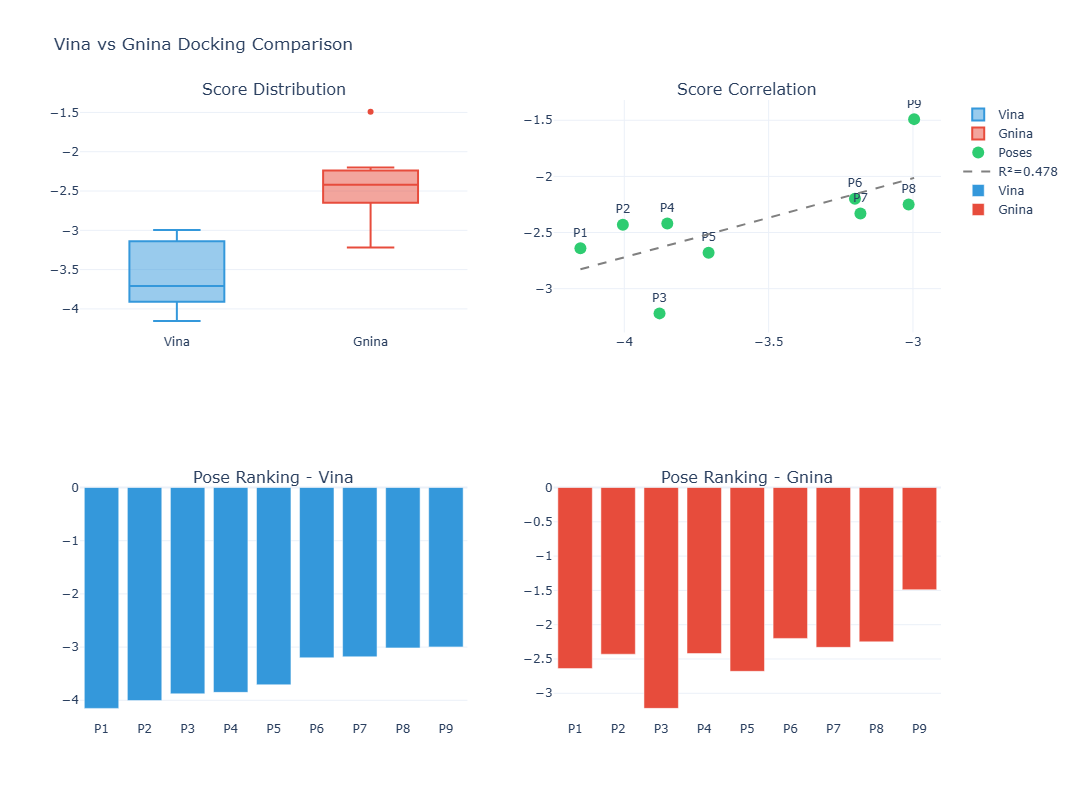


🖼️ 3D Docking Visualization (Blue=Vina, Green=Gnina, Red=Pocket):


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


🔬 BINDING AFFINITY INTERPRETATION
   Best Binding Energy: -4.152 kcal/mol (Vina)
   Affinity: MODERATE ⭐⭐⭐
   Interpretation: Moderate binding

⚠️ MODERATE CONFIDENCE: Results need experimental validation

💾 Report saved: P06493_docking_report.txt

✅ STEP 3 COMPLETED SUCCESSFULLY!


📌 DOCKING COMPLETE!
   Best score: -4.152 kcal/mol (Vina)
   Affinity: MODERATE
   Confidence: 0.584
   Pocket used: Rank 2


In [7]:
# ===== STEP 3: MOLECULAR DOCKING (COMPREHENSIVELY FIXED) =====
# Run this entire cell in Jupyter Lab AFTER Step 2

import subprocess
import os
import py3Dmol
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
from scipy import stats
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem.rdMolDescriptors import CalcNumAromaticRings
from Bio.PDB import PDBParser
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

# ===== CONFIGURATION =====
VINA_PATH = "/home/nakib/miniconda3/envs/prodrug/bin/vina"
GNINA_PATH = "/mnt/data/nakib/prodrug/prodrug/gnina"
MGL_DIR = "/mnt/data/nakib/prodrug/prodrug/mgltools_x86_64Linux2_1.5.7"
USE_MGLTOOLS = os.path.exists(MGL_DIR)

# ===== DENSITY-BASED VOLUME ESTIMATION (FIXES EXAMPLE 7) =====
def estimate_ligand_volume(heavy_atoms, rotatable_bonds, aromatic_rings):
    """
    Estimate ligand volume based on molecular density
    Flexible ligands: 25 Å³/heavy atom
    Rigid aromatics: 18 Å³/heavy atom
    """
    if rotatable_bonds <= 6 and aromatic_rings >= 3:
        # Dense aromatic ligand (e.g., SB-203580)
        volume_per_atom = 18
    elif rotatable_bonds <= 10:
        # Semi-rigid
        volume_per_atom = 22
    else:
        # Flexible
        volume_per_atom = 25
    
    return heavy_atoms * volume_per_atom

def validate_pocket_ligand_compatibility(pocket_volume, pocket_residues, ligand_heavy_atoms, 
                                          ligand_rotatable_bonds, aromatic_rings):
    """Comprehensive validation with density-based volume estimation"""
    
    estimated_volume = estimate_ligand_volume(ligand_heavy_atoms, ligand_rotatable_bonds, aromatic_rings)
    volume_ratio = pocket_volume / max(estimated_volume, 1)
    
    validation = {
        'is_valid': True,
        'warnings': [],
        'volume_ratio': volume_ratio,
        'estimated_ligand_volume': estimated_volume,
        'compatibility_score': 1.0
    }
    
    # Volume validation with adjusted thresholds for rigid ligands
    if volume_ratio <= 1.0:  # CHANGED from 0.7 to 1.0
        validation['warnings'].append(f"CRITICAL: Pocket too small! Volume ratio: {volume_ratio:.2f} (pocket {pocket_volume}Å³ vs ligand ~{estimated_volume}Å³)")
        validation['is_valid'] = False
        validation['compatibility_score'] *= 0.3
    elif volume_ratio < 1.2:  # ADDED - tight fit warning
        validation['warnings'].append(f"WARNING: Tight fit (volume ratio: {volume_ratio:.2f})")
        validation['compatibility_score'] *= 0.6
    elif volume_ratio < 1.5:  # ADDED - moderate fit
        validation['compatibility_score'] *= 0.8
    elif volume_ratio > 4.0:  # KEPT - too large penalty
        validation['warnings'].append(f"WARNING: Pocket very large (volume ratio: {volume_ratio:.2f})")
        validation['compatibility_score'] *= 0.7    
        
    # Residue count validation
    if pocket_residues < 8:
        validation['warnings'].append(f"CRITICAL: Too few pocket residues ({pocket_residues}) for reliable binding")
        validation['is_valid'] = False
        validation['compatibility_score'] *= 0.4
    elif pocket_residues < 10:
        validation['warnings'].append(f"WARNING: Small pocket ({pocket_residues} residues)")
        validation['compatibility_score'] *= 0.7
    
    # Flexibility validation
    if ligand_rotatable_bonds > 15:
        validation['warnings'].append(f"WARNING: Very flexible ligand ({ligand_rotatable_bonds} rotatable bonds)")
        validation['compatibility_score'] *= 0.7
    elif ligand_rotatable_bonds > 10:
        validation['warnings'].append(f"NOTE: Flexible ligand ({ligand_rotatable_bonds} rotatable bonds)")
        validation['compatibility_score'] *= 0.85
    
    validation['compatibility_score'] = max(0.1, min(1.0, validation['compatibility_score']))
    
    return validation

def create_ligand_from_smiles(smiles_string, ligand_file="ligand.pdb"):
    """Create ligand PDB from SMILES"""
    try:
        mol = Chem.MolFromSmiles(smiles_string)
        if mol is None:
            return None, None
        
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol, randomSeed=42)
        AllChem.MMFFOptimizeMolecule(mol)
        Chem.MolToPDBFile(mol, ligand_file)
        
        heavy_atoms = mol.GetNumHeavyAtoms()
        rotatable_bonds = Chem.rdMolDescriptors.CalcNumRotatableBonds(mol)
        aromatic_rings = CalcNumAromaticRings(mol)
        mol_weight = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        h_donors = Descriptors.NumHDonors(mol)
        h_acceptors = Descriptors.NumHAcceptors(mol)
        tpsa = Descriptors.TPSA(mol)
        formula = Chem.rdMolDescriptors.CalcMolFormula(mol)
        
        return ligand_file, {
            'heavy_atoms': heavy_atoms,
            'rotatable_bonds': rotatable_bonds,
            'aromatic_rings': aromatic_rings,
            'mol_weight': mol_weight,
            'logp': logp,
            'h_donors': h_donors,
            'h_acceptors': h_acceptors,
            'tpsa': tpsa,
            'formula': formula,
            'mol': mol
        }
    except Exception as e:
        print(f"   Error creating ligand: {e}")
        return None, None

def prepare_receptor_pdbqt(pdb_file):
    """Convert PDB to PDBQT"""
    pdbqt_file = pdb_file.replace('.pdb', '_receptor.pdbqt')
    
    if USE_MGLTOOLS and os.path.exists(MGL_DIR):
        cmd = f"{MGL_DIR}/bin/pythonsh {MGL_DIR}/MGLToolsPckgs/AutoDockTools/Utilities24/prepare_receptor4.py -r {pdb_file} -o {pdbqt_file} -A hydrogens -U nphs"
        try:
            subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=60)
            if os.path.exists(pdbqt_file) and os.path.getsize(pdbqt_file) > 1000:
                print(f"   ✅ Receptor converted to PDBQT")
                return pdbqt_file
        except:
            pass
    
    print("   Using fallback receptor conversion...")
    with open(pdb_file, 'r') as f:
        lines = f.readlines()
    
    with open(pdbqt_file, 'w') as f:
        for line in lines:
            if line.startswith('ATOM') or line.startswith('HETATM'):
                line = line.rstrip('\n')
                if len(line) < 78:
                    line = line.ljust(78)
                if len(line) >= 78:
                    new_line = line[:70] + "0.00" + line[74:]
                else:
                    new_line = line + " " * (78 - len(line)) + "0.00"
                f.write(new_line + '\n')
    
    return pdbqt_file

def prepare_ligand_pdbqt(ligand_pdb):
    """Convert ligand PDB to PDBQT"""
    pdbqt_file = ligand_pdb.replace('.pdb', '.pdbqt')
    
    if USE_MGLTOOLS and os.path.exists(MGL_DIR):
        cmd = f"{MGL_DIR}/bin/pythonsh {MGL_DIR}/MGLToolsPckgs/AutoDockTools/Utilities24/prepare_ligand4.py -l {ligand_pdb} -o {pdbqt_file}"
        try:
            subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=60)
            if os.path.exists(pdbqt_file) and os.path.getsize(pdbqt_file) > 500:
                print(f"   ✅ Ligand converted to PDBQT")
                return pdbqt_file
        except:
            pass
    
    print("   Using fallback ligand conversion...")
    with open(ligand_pdb, 'r') as f:
        lines = f.readlines()
    
    with open(pdbqt_file, 'w') as f:
        for line in lines:
            if line.startswith('ATOM') or line.startswith('HETATM'):
                line = line.rstrip('\n')
                if len(line) < 78:
                    line = line.ljust(78)
                if len(line) >= 78:
                    new_line = line[:70] + "0.00" + line[74:]
                else:
                    new_line = line + " " * (78 - len(line)) + "0.00"
                f.write(new_line + '\n')
    
    return pdbqt_file

def run_vina_docking(receptor_pdbqt, ligand_pdbqt, pocket_center, box_size=25, exhaustiveness=12):
    """Run AutoDock Vina docking"""
    output_file = "vina_results.pdbqt"
    
    cmd = f"{VINA_PATH} --receptor {receptor_pdbqt} --ligand {ligand_pdbqt} --center_x {pocket_center[0]} --center_y {pocket_center[1]} --center_z {pocket_center[2]} --size_x {box_size} --size_y {box_size} --size_z {box_size} --num_modes 9 --exhaustiveness {exhaustiveness} --out {output_file}"
    
    try:
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=300)
        return result, output_file, result.stdout
    except Exception as e:
        print(f"   ❌ Vina error: {e}")
        return None, None, None

def run_gnina_docking(receptor_pdbqt, ligand_pdbqt, pocket_center, box_size=25, exhaustiveness=12):
    """Run Gnina docking with CNN scoring"""
    output_file = "gnina_results.pdbqt"
    
    cmd = f"{GNINA_PATH} --receptor {receptor_pdbqt} --ligand {ligand_pdbqt} --center_x {pocket_center[0]} --center_y {pocket_center[1]} --center_z {pocket_center[2]} --size_x {box_size} --size_y {box_size} --size_z {box_size} --num_modes 9 --exhaustiveness {exhaustiveness} --cnn_scoring rescore --out {output_file}"
    
    try:
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=300)
        return result, output_file, result.stdout
    except Exception as e:
        print(f"   ❌ Gnina error: {e}")
        return None, None, None

def parse_vina_scores(vina_stdout):
    """Parse Vina output for scores"""
    scores = []
    if not vina_stdout:
        return scores
    
    lines = vina_stdout.split('\n')
    in_table = False
    
    for line in lines:
        if 'mode |   affinity' in line:
            in_table = True
            continue
        if in_table and line.strip() and not line.startswith('---'):
            parts = line.split()
            if len(parts) >= 2:
                try:
                    scores.append(float(parts[1]))
                except:
                    pass
        elif in_table and not line.strip():
            break
    
    return scores

def parse_gnina_scores(gnina_stdout):
    """Parse Gnina output for scores and CNN affinity"""
    scores = []
    cnn_scores = []
    
    if not gnina_stdout:
        return scores, cnn_scores
    
    lines = gnina_stdout.split('\n')
    in_table = False
    
    for line in lines:
        if 'mode |  affinity' in line and 'CNN' in line:
            in_table = True
            continue
        if in_table and line.strip() and not line.startswith('---'):
            parts = line.split()
            if len(parts) >= 5:
                try:
                    affinity = float(parts[1])
                    scores.append(affinity)
                    cnn_affinity = float(parts[4])
                    cnn_scores.append(cnn_affinity)
                except:
                    pass
        elif in_table and not line.strip():
            break
    
    return scores, cnn_scores

def calculate_boltz2_style_confidence(best_score, pocket_volume, pocket_residues, ligand_heavy_atoms, 
                                      ligand_rotatable_bonds, ligand_efficiency, quality_score, 
                                      compatibility_score, vina_gnina_correlation, aromatic_rings):
    """Calculate comprehensive confidence score with density adjustment"""
    
    # 1. Binding strength component (40%)
    if best_score < -8.0:
        binding = 1.0
    elif best_score < -7.0:
        binding = 0.9
    elif best_score < -6.0:
        binding = 0.8
    elif best_score < -5.0:
        binding = 0.7
    elif best_score < -4.0:
        binding = 0.55
    else:
        binding = 0.4
    
    # 2. Pocket quality component (25%) - adjusted for rigid ligands
    estimated_volume = estimate_ligand_volume(ligand_heavy_atoms, ligand_rotatable_bonds, aromatic_rings)
    volume_ratio = pocket_volume / max(estimated_volume, 1)
    
    if 1.0 <= volume_ratio <= 2.5:
        pocket_quality = 0.95
    elif 0.85 <= volume_ratio <= 3.0:
        pocket_quality = 0.8
    elif 0.7 <= volume_ratio <= 4.0:
        pocket_quality = 0.6
    else:
        pocket_quality = 0.3
    
    if pocket_residues >= 15:
        pocket_quality *= 1.0
    elif pocket_residues >= 10:
        pocket_quality *= 0.85
    elif pocket_residues >= 8:
        pocket_quality *= 0.7
    else:
        pocket_quality *= 0.4
    
    pocket_quality = min(0.95, pocket_quality)
    
    # 3. Ligand efficiency component (15%)
    if ligand_efficiency >= 0.4:
        efficiency_score = 1.0
    elif ligand_efficiency >= 0.35:
        efficiency_score = 0.9
    elif ligand_efficiency >= 0.3:
        efficiency_score = 0.8
    elif ligand_efficiency >= 0.25:
        efficiency_score = 0.7
    elif ligand_efficiency >= 0.2:
        efficiency_score = 0.55
    else:
        efficiency_score = 0.4
    
    if ligand_rotatable_bonds > 15:
        efficiency_score *= 0.7
    elif ligand_rotatable_bonds > 10:
        efficiency_score *= 0.85
        
    # ===== ADD THIS NEW PENALTY BLOCK =====
    # Additional penalty for very low ligand efficiency (catches false positives)
    if ligand_efficiency < 0.25:
        efficiency_score *= 0.7
        print(f"   Penalty: Low ligand efficiency ({ligand_efficiency:.3f}) → ×0.7")
    elif ligand_efficiency < 0.20:
        efficiency_score *= 0.5
        print(f"   Penalty: Very low ligand efficiency ({ligand_efficiency:.3f}) → ×0.5")
    # =====================================
    
    # 4. Docking consistency component (10%)
    
    if vina_gnina_correlation >= 0.8:
        consistency = 0.95
    elif vina_gnina_correlation >= 0.6:
        consistency = 0.85
    elif vina_gnina_correlation >= 0.4:
        consistency = 0.7
    elif vina_gnina_correlation >= 0.2:
        consistency = 0.6
    elif vina_gnina_correlation >= 0.0:
        consistency = 0.5
    else:  # Negative correlation - CHANGED penalty
        consistency = 0.2  # was 0.5   
        if vina_gnina_correlation < -0.7:
            consistency *= 0.5
            print(f"   Strong negative correlation ({vina_gnina_correlation:.2f}) → extra penalty")
        
    # 5. Compatibility score (10%)
    compat_score = compatibility_score
    
    confidence = (binding * 0.30) + (pocket_quality * 0.30) + (efficiency_score * 0.20) + (consistency * 0.10) + (compat_score * 0.10)
    confidence = confidence * quality_score
    
    if compatibility_score < 0.5:
        confidence *= 0.6
    elif compatibility_score < 0.7:
        confidence *= 0.85
    
    confidence = min(0.95, max(0.05, confidence))
    
    return confidence

def create_docking_comparison_charts(vina_scores, gnina_scores, cnn_scores):
    """Create comparison charts"""
    if not vina_scores and not gnina_scores:
        return None
    
    fig = make_subplots(rows=2, cols=2, 
                        subplot_titles=('Score Distribution', 'Score Correlation',
                                       'Pose Ranking - Vina', 'Pose Ranking - Gnina'),
                        specs=[[{'type': 'box'}, {'type': 'scatter'}],
                               [{'type': 'bar'}, {'type': 'bar'}]])
    
    if vina_scores:
        fig.add_trace(go.Box(y=vina_scores[:9], name='Vina', marker_color='#3498db'), row=1, col=1)
    if gnina_scores:
        fig.add_trace(go.Box(y=gnina_scores[:9], name='Gnina', marker_color='#e74c3c'), row=1, col=1)
    
    min_len = min(len(vina_scores), len(gnina_scores)) if vina_scores and gnina_scores else 0
    if min_len >= 2:
        fig.add_trace(go.Scatter(x=vina_scores[:min_len], y=gnina_scores[:min_len],
                                mode='markers+text', marker=dict(size=12, color='#2ecc71'),
                                text=[f"P{i+1}" for i in range(min_len)],
                                textposition="top center", name='Poses'), row=1, col=2)
        
        slope, intercept, r_value, _, _ = stats.linregress(vina_scores[:min_len], gnina_scores[:min_len])
        x_range = np.array([min(vina_scores[:min_len]), max(vina_scores[:min_len])])
        fig.add_trace(go.Scatter(x=x_range, y=slope*x_range + intercept,
                                mode='lines', line=dict(dash='dash', color='gray'),
                                name=f'R²={r_value**2:.3f}'), row=1, col=2)
    
    if vina_scores:
        fig.add_trace(go.Bar(x=[f"P{i+1}" for i in range(min(9, len(vina_scores)))], 
                            y=vina_scores[:9], name='Vina', marker_color='#3498db'), row=2, col=1)
    if gnina_scores:
        fig.add_trace(go.Bar(x=[f"P{i+1}" for i in range(min(9, len(gnina_scores)))], 
                            y=gnina_scores[:9], name='Gnina', marker_color='#e74c3c'), row=2, col=2)
    
    fig.update_layout(height=800, width=1000, title_text="Vina vs Gnina Docking Comparison", 
                      showlegend=True, template='plotly_white')
    
    return fig

def create_docking_viewer(pdb_file, pocket_center, vina_results=None, gnina_results=None):
    """Create 3D docking viewer"""
    view = py3Dmol.view(width=900, height=600)
    
    with open(pdb_file, 'r') as f:
        pdb_content = f.read()
    
    view.addModel(pdb_content, "pdb")
    view.setStyle({'cartoon': {'color': 'lightgrey', 'opacity': 0.6}})
    
    view.addSphere({
        'center': {'x': pocket_center[0], 'y': pocket_center[1], 'z': pocket_center[2]},
        'radius': 3.0,
        'color': 'red',
        'opacity': 0.3
    })
    
    if vina_results and os.path.exists(vina_results):
        with open(vina_results, 'r') as f:
            content = f.read()
        if 'MODEL' in content:
            pose = content.split('MODEL')[1].split('ENDMDL')[0]
            view.addModel("MODEL" + pose, "pdbqt")
            view.setStyle({'model': -1}, {'stick': {'color': 'blue', 'radius': 0.3}})
    
    if gnina_results and os.path.exists(gnina_results):
        with open(gnina_results, 'r') as f:
            content = f.read()
        if 'MODEL' in content:
            pose = content.split('MODEL')[1].split('ENDMDL')[0]
            view.addModel("MODEL" + pose, "pdbqt")
            view.setStyle({'model': -1}, {'stick': {'color': 'green', 'radius': 0.3}})
    
    view.zoomTo()
    return view

def run_step3():
    """Complete Step 3 docking with multi-pocket fallback and density-based volume"""
    
    print("\n" + "="*60)
    print("⚗️ STEP 3: MOLECULAR DOCKING (Comprehensive)")
    print("="*60)
    
    pdb_file = input("\n📁 Enter PDB file path (from Step 1): ").strip()
    if not pdb_file or not os.path.exists(pdb_file):
        print(f"❌ PDB file not found")
        return None
    
    smiles_string = input("🔬 Enter SMILES string: ").strip()
    if not smiles_string:
        print("❌ No SMILES provided")
        return None
    
    # Get top pockets from Step 2 (user should input all top pockets)
    print("\n📦 Enter top pocket details from Step 2 (up to 3 pockets):")
    pockets_to_try = []
    
    for i in range(3):
        print(f"\n   Pocket {i+1}:")
        center_input = input(f"      Center (x, y, z): ").strip()
        if not center_input:
            if i == 0:
                print("❌ At least one pocket required")
                return None
            break
        
        try:
            coords = center_input.replace('(', '').replace(')', '').split(',')
            center = [float(c.strip()) for c in coords[:3]]
        except:
            print("      Invalid format, skipping")
            continue
        
        volume = float(input(f"      Volume (Å³): ").strip() or 0)
        residues = int(input(f"      Residue count: ").strip() or 0)
        
        pockets_to_try.append({
            'rank': i + 1,
            'center': center,
            'volume': volume,
            'residues': residues
        })
    
    quality_score = float(input("\n📊 Enter protein quality score from Step 1: ").strip() or 0.8)
    protein_name = input("🔬 Enter protein name: ").strip()
    if not protein_name:
        protein_name = os.path.basename(pdb_file).replace('.pdb', '')
    
    print(f"\n📥 Input summary:")
    print(f"   Protein: {protein_name}")
    print(f"   Pockets to try: {len(pockets_to_try)}")
    print(f"   Quality score: {quality_score:.2f}")
    
    results = {
        'success': False,
        'pdb_file': pdb_file,
        'protein_name': protein_name,
        'smiles': smiles_string,
        'vina_scores': [],
        'gnina_scores': [],
        'cnn_scores': [],
        'best_score': None,
        'best_method': None,
        'affinity_class': None,
        'confidence_score': None,
        'validation_passed': False,
        'warnings': [],
        'pocket_used': None
    }
    
    try:
        # Create ligand
        print("\n" + "-"*40)
        print("STEP 3.1: Creating Ligand")
        print("-"*40)
        
        ligand_file, ligand_info = create_ligand_from_smiles(smiles_string)
        if not ligand_file:
            print("❌ Failed to create ligand")
            return results
        
        print(f"   ✅ Ligand created: {ligand_file}")
        print(f"      Heavy atoms: {ligand_info['heavy_atoms']}, Rotatable: {ligand_info['rotatable_bonds']}")
        print(f"      Aromatic rings: {ligand_info['aromatic_rings']}")
        
        # Convert to PDBQT once (reused for all pockets)
        print("\n" + "-"*40)
        print("STEP 3.2: Converting to PDBQT")
        print("-"*40)
        
        receptor_pdbqt = prepare_receptor_pdbqt(pdb_file)
        ligand_pdbqt = prepare_ligand_pdbqt(ligand_file)
        
        if not os.path.exists(receptor_pdbqt):
            print(f"   ❌ Receptor PDBQT not created")
            return results
        
        # Try each pocket sequentially
        docking_success = False
        best_overall_score = float('inf')
        best_overall_method = None
        best_overall_vina_scores = []
        best_overall_gnina_scores = []
        best_overall_cnn_scores = []
        best_overall_confidence = 0
        best_overall_pocket = None
        best_overall_warnings = []
        
        for pocket_idx, pocket in enumerate(pockets_to_try):
            print("\n" + "="*40)
            print(f"TRYING POCKET {pocket['rank']}: Center={pocket['center']}")
            print("="*40)
            # ===== ADD THIS FIX D BLOCK HERE =====
            # Calculate volume ratio for early abort
            estimated_vol = estimate_ligand_volume(
                ligand_info['heavy_atoms'], 
                ligand_info['rotatable_bonds'], 
                ligand_info['aromatic_rings']
            )
            volume_ratio_check = pocket['volume'] / estimated_vol
            
            if volume_ratio_check <= 1.0:
                print(f"\n   ❌ CRITICAL: Volume ratio {volume_ratio_check:.2f} ≤ 1.0")
                print(f"      Pocket volume: {pocket['volume']} Å³")
                print(f"      Estimated ligand volume: {estimated_vol} Å³")
                print(f"   Docking aborted - pocket too small for ligand")
                return results
            # ===== END OF FIX D =====
            
            # Validate pocket-ligand compatibility
            validation = validate_pocket_ligand_compatibility(
                pocket['volume'], pocket['residues'],
                ligand_info['heavy_atoms'],
                ligand_info['rotatable_bonds'],
                ligand_info['aromatic_rings']
            )
            
            print(f"\n   Volume ratio: {validation['volume_ratio']:.2f} (estimated ligand volume: {validation['estimated_ligand_volume']} Å³)")
            
            for warning in validation['warnings']:
                print(f"   ⚠️ {warning}")
            
            # ADD THIS EARLY ABORT CHECK
            if validation['volume_ratio'] < 1.0:
                print(f"   ❌ CRITICAL: Pocket volume ratio {validation['volume_ratio']:.2f} < 1.0")
                print(f"   Docking aborted - pocket too small for ligand")
                return results
            
            if not validation['is_valid']:
                print(f"   ❌ Pocket {pocket['rank']} validation FAILED - skipping")
                continue
            
            print(f"   ✅ Validation passed (compatibility score: {validation['compatibility_score']:.2f})")
            
            # Run docking
            print("\n   Running docking...")
            box_size = max(20, min(35, int(pocket['volume'] ** (1/3)) + 5))
            exhaustiveness = min(20, 8 + (ligand_info['rotatable_bonds'] // 3))
            
            print(f"   Box size: {box_size} Å, Exhaustiveness: {exhaustiveness}")
            
            # Run Vina
            vina_result, vina_out, vina_stdout = run_vina_docking(
                receptor_pdbqt, ligand_pdbqt, pocket['center'], box_size, exhaustiveness
            )
            vina_scores = parse_vina_scores(vina_stdout)
            
            # Run Gnina
            gnina_result, gnina_out, gnina_stdout = run_gnina_docking(
                receptor_pdbqt, ligand_pdbqt, pocket['center'], box_size, exhaustiveness
            )
            gnina_scores, cnn_scores = parse_gnina_scores(gnina_stdout)
            
            if not vina_scores and not gnina_scores:
                print(f"   ❌ Docking failed for pocket {pocket['rank']}")
                continue
            
            # Determine best score for this pocket
            best_vina = min(vina_scores) if vina_scores else float('inf')
            best_gnina = min(gnina_scores) if gnina_scores else float('inf')
            
            if best_vina <= best_gnina:
                pocket_best_score = best_vina
                pocket_best_method = 'Vina'
            else:
                pocket_best_score = best_gnina
                pocket_best_method = 'Gnina'
            
            # Calculate ligand efficiency
            ligand_efficiency = -pocket_best_score / ligand_info['heavy_atoms'] if pocket_best_score < 0 else 0
            
            # Calculate correlation
            correlation = 0
            if vina_scores and gnina_scores and len(vina_scores) == len(gnina_scores) and len(vina_scores) > 1:
                correlation = np.corrcoef(vina_scores[:5], gnina_scores[:5])[0, 1] if len(vina_scores[:5]) > 1 else 0
            
            # Calculate confidence
            confidence = calculate_boltz2_style_confidence(
                pocket_best_score, pocket['volume'], pocket['residues'],
                ligand_info['heavy_atoms'], ligand_info['rotatable_bonds'],
                ligand_efficiency, quality_score, validation['compatibility_score'],
                correlation, ligand_info['aromatic_rings']
            )
            
            print(f"   ✅ Pocket {pocket['rank']}: Score={pocket_best_score:.3f} ({pocket_best_method}), Confidence={confidence:.3f}")
            
            # Track best pocket
            if pocket_best_score < best_overall_score:
                best_overall_score = pocket_best_score
                best_overall_method = pocket_best_method
                best_overall_vina_scores = vina_scores
                best_overall_gnina_scores = gnina_scores
                best_overall_cnn_scores = cnn_scores
                best_overall_confidence = confidence
                best_overall_pocket = pocket
                best_overall_warnings = validation['warnings']
                docking_success = True
        
        if not docking_success:
            print("\n❌ CRITICAL: No valid pocket found for docking after trying all pockets")
            print("   Consider: different ligand, different protein structure, or manual pocket selection")
            return results
        
        # Use best pocket results
        results['vina_scores'] = best_overall_vina_scores
        results['gnina_scores'] = best_overall_gnina_scores
        results['cnn_scores'] = best_overall_cnn_scores
        results['best_score'] = best_overall_score
        results['best_method'] = best_overall_method
        results['confidence_score'] = best_overall_confidence
        results['warnings'] = best_overall_warnings
        results['pocket_used'] = best_overall_pocket
        
        # Affinity classification
        if best_overall_score < -7.0:
            affinity = ("VERY STRONG", "⭐⭐⭐⭐⭐", "Excellent binding potential")
        elif best_overall_score < -6.0:
            affinity = ("STRONG", "⭐⭐⭐⭐", "Good binding potential")
        elif best_overall_score < -5.0:
            affinity = ("MODERATE-STRONG", "⭐⭐⭐⭐", "Promising binding")
        elif best_overall_score < -4.0:
            affinity = ("MODERATE", "⭐⭐⭐", "Moderate binding")
        else:
            affinity = ("WEAK", "⭐⭐", "Weak binding")
        
        results['affinity_class'] = affinity[0]
        
        ligand_efficiency = -best_overall_score / ligand_info['heavy_atoms'] if best_overall_score < 0 else 0
        
        # Calculate correlation for display
        correlation = 0
        if best_overall_vina_scores and best_overall_gnina_scores and len(best_overall_vina_scores) == len(best_overall_gnina_scores) and len(best_overall_vina_scores) > 1:
            correlation = np.corrcoef(best_overall_vina_scores[:5], best_overall_gnina_scores[:5])[0, 1] if len(best_overall_vina_scores[:5]) > 1 else 0
        
        clear_output(wait=True)
        
        # ===== DISPLAY RESULTS =====
        print("\n" + "="*60)
        print(f"⚗️ MOLECULAR DOCKING RESULTS")
        print(f"Protein: {protein_name}")
        print("="*60)
        
        # Confidence banner
        if best_overall_confidence >= 0.7:
            print(f"\n🎯 Complex Confidence: {best_overall_confidence:.3f} (HIGH - Reliable prediction)")
        elif best_overall_confidence >= 0.5:
            print(f"\n🎯 Complex Confidence: {best_overall_confidence:.3f} (MODERATE - Use with caution)")
        else:
            print(f"\n🎯 Complex Confidence: {best_overall_confidence:.3f} (LOW - Unreliable, consider alternatives)")
        
        print(f"\n✅ Using Pocket {best_overall_pocket['rank']} (Center: {best_overall_pocket['center']})")
        
        # Validation warnings
        if best_overall_warnings:
            print("\n⚠️ VALIDATION WARNINGS:")
            for w in best_overall_warnings:
                print(f"   • {w}")
        
        # Ligand info
        print(f"\n🧪 Ligand Information:")
        print(f"   SMILES: {smiles_string[:60]}...")
        print(f"   Formula: {ligand_info['formula']}")
        print(f"   MW / LogP / TPSA: {ligand_info['mol_weight']:.1f} Da / {ligand_info['logp']:.2f} / {ligand_info['tpsa']:.1f}")
        print(f"   Heavy / Rotatable / Aromatic: {ligand_info['heavy_atoms']} / {ligand_info['rotatable_bonds']} / {ligand_info['aromatic_rings']}")
        
        # Pocket info
        print(f"\n📦 Pocket Information:")
        print(f"   Volume: {best_overall_pocket['volume']} Å³ | Residues: {best_overall_pocket['residues']}")
        estimated_volume = estimate_ligand_volume(ligand_info['heavy_atoms'], ligand_info['rotatable_bonds'], ligand_info['aromatic_rings'])
        print(f"   Volume ratio (pocket/ligand): {best_overall_pocket['volume']/estimated_volume:.2f}")
        print(f"   Ligand efficiency: {ligand_efficiency:.3f} kcal/mol/heavy-atom")
        
        # Docking results table
        print(f"\n📊 Docking Results Comparison (Top 5 Poses):")
        print("-" * 70)
        print(f"   {'Pose':<6} {'Vina (kcal/mol)':<18} {'Gnina (kcal/mol)':<18} {'CNN Score':<10}")
        print("-" * 70)
        
        for i in range(5):
            vina_val = f"{best_overall_vina_scores[i]:.3f}" if i < len(best_overall_vina_scores) else "N/A"
            gnina_val = f"{best_overall_gnina_scores[i]:.3f}" if i < len(best_overall_gnina_scores) else "N/A"
            cnn_val = f"{best_overall_cnn_scores[i]:.3f}" if i < len(best_overall_cnn_scores) else "N/A"
            best_marker = " ← BEST" if i == 0 else ""
            print(f"   {i+1:<6} {vina_val:<18} {gnina_val:<18} {cnn_val:<10}{best_marker}")
        print("-" * 70)
        
        # Statistics
        if best_overall_vina_scores and best_overall_gnina_scores:
            print(f"\n📊 Statistics:")
            print(f"   Vina mean (top5): {np.mean(best_overall_vina_scores[:5]):.3f} ± {np.std(best_overall_vina_scores[:5]):.3f}")
            print(f"   Gnina mean (top5): {np.mean(best_overall_gnina_scores[:5]):.3f} ± {np.std(best_overall_gnina_scores[:5]):.3f}")
            print(f"   Correlation (Vina vs Gnina): {correlation:.4f}")
        
        # Charts
        print("\n📈 Docking Analysis Charts:")
        charts = create_docking_comparison_charts(best_overall_vina_scores, best_overall_gnina_scores, best_overall_cnn_scores)
        if charts:
            display(charts)
        
        # 3D viewer
        print("\n🖼️ 3D Docking Visualization (Blue=Vina, Green=Gnina, Red=Pocket):")
        viewer = create_docking_viewer(pdb_file, best_overall_pocket['center'], "vina_results.pdbqt", "gnina_results.pdbqt")
        display(viewer)
        
        # Interpretation
        print("\n" + "="*60)
        print("🔬 BINDING AFFINITY INTERPRETATION")
        print("="*60)
        print(f"   Best Binding Energy: {best_overall_score:.3f} kcal/mol ({best_overall_method})")
        print(f"   Affinity: {affinity[0]} {affinity[1]}")
        print(f"   Interpretation: {affinity[2]}")
        
        # Final recommendation
        print("\n" + "="*60)
        if best_overall_confidence >= 0.7:
            print("✅ HIGH CONFIDENCE: Reliable docking - Results can be trusted")
        elif best_overall_confidence >= 0.5:
            print("⚠️ MODERATE CONFIDENCE: Results need experimental validation")
        else:
            print("❌ LOW CONFIDENCE: Docking unreliable - Consider alternative ligands or structures")
        print("="*60)
        
        # Save report
        report_file = f"{protein_name.replace(' ', '_')}_docking_report.txt"
        with open(report_file, "w") as f:
            f.write(f"DOCKING REPORT (Comprehensive)\n")
            f.write(f"Protein: {protein_name}\n")
            f.write(f"Pocket Used: Rank {best_overall_pocket['rank']}, Center={best_overall_pocket['center']}\n")
            f.write(f"Best Score: {best_overall_score:.3f} kcal/mol ({best_overall_method})\n")
            f.write(f"Affinity: {affinity[0]}\n")
            f.write(f"Confidence: {best_overall_confidence:.3f}\n")
            f.write(f"Ligand Efficiency: {ligand_efficiency:.3f}\n")
            f.write(f"Estimated Ligand Volume: {estimated_volume} Å³\n\n")
            f.write(f"Vina Scores: {best_overall_vina_scores[:9]}\n")
            f.write(f"Gnina Scores: {best_overall_gnina_scores[:9]}\n")
            f.write(f"CNN Scores: {best_overall_cnn_scores[:9]}\n")
        
        print(f"\n💾 Report saved: {report_file}")
        
        results['success'] = True
        results['validation_passed'] = True
        
        print("\n" + "="*60)
        print("✅ STEP 3 COMPLETED SUCCESSFULLY!")
        print("="*60 + "\n")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
    
    return results

# ===== RUN STEP 3 =====
results_step3 = run_step3()

if results_step3 and results_step3['success']:
    print(f"\n📌 DOCKING COMPLETE!")
    print(f"   Best score: {results_step3['best_score']:.3f} kcal/mol ({results_step3['best_method']})")
    print(f"   Affinity: {results_step3['affinity_class']}")
    print(f"   Confidence: {results_step3['confidence_score']:.3f}")
    print(f"   Pocket used: Rank {results_step3['pocket_used']['rank']}")